# `gearygram` — spatial autocorrelation as a function of distance

`gearygram` computes Geary's C correlogram: how spatial autocorrelation (or multivariate co-variation) changes with distance.  It supports three modes:

| Mode | When to use |
|---|---|
| **Bandwidth** (default) | Kernel-weighted Geary's C at *n_bins* increasing bandwidths |
| **kNN** (`max_k`) | Cumulative k-NN Geary's C for k = 1 ... max_k |
| **Nonparametric** (`nonparametric=True`) | LOWESS smooth of per-pair contributions vs distance^2 |

For multivariate data (p > 1) the statistic is the Anselin (2019) multivariate Geary's C: the mean of all p per-variable values. This is likely the most useful situation for the gearygram.

Values < 1 indicate positive spatial autocorrelation; values > 1 indicate negative autocorrelation; 1 = no autocorrelation.


In [6]:
import numpy
import geopandas
import geodatasets
import matplotlib.pyplot as plt
from spml.metrics import gearygram

gdf = geopandas.read_file(geodatasets.get_path('geoda guerry')).to_crs('EPSG:27572')

VARS_MULTI = ['Crm_prs', 'Crm_prp', 'Litercy', 'Donatns', 'Infants', 'Suicids', 'Wealth', 'Commerc']
MAX_DIST = 900_000  # metres

print(f'n = {len(gdf)} French departments')
print(f'Variables: {VARS_MULTI}')
gdf[VARS_MULTI].describe().round(1)

n = 85 French departments
Variables: ['Crm_prs', 'Crm_prp', 'Litercy', 'Donatns', 'Infants', 'Suicids', 'Wealth', 'Commerc']


,Crm_prs,Crm_prp,Litercy,Donatns,Infants,Suicids,Wealth,Commerc
count,85.0,85.0,85.0,85.0,85.0,85.0,85.0,85.0
mean,19960.9,7881.3,39.1,6723.3,18982.9,36516.8,43.6,42.3
std,7299.2,3048.6,17.4,4863.2,8850.6,31498.3,25.1,24.8
min,5883.0,1368.0,12.0,1246.0,2660.0,3460.0,1.0,1.0
25%,14790.0,5990.0,25.0,3446.0,14281.0,15400.0,22.0,21.0
50%,18785.0,7624.0,38.0,4964.0,17044.0,26198.0,44.0,42.0
75%,26221.0,9190.0,52.0,9242.0,21981.0,45180.0,65.0,63.0
max,37014.0,20235.0,74.0,27830.0,62486.0,163241.0,86.0,86.0


## Bandwidth mode

Each call evaluates kernel-weighted Geary's C at a series of increasing bandwidth values from 0 to `max_distance`.  At bandwidth *h*, pair (*i*, *j*) at distance *d* contributes weight K(d/h).  Two kernels are compared:

- **Gaussian** (non-compact): all pairs contribute at every bandwidth
- **Bisquare** (compact): only pairs within *h* contribute; uses a sparse distance matrix


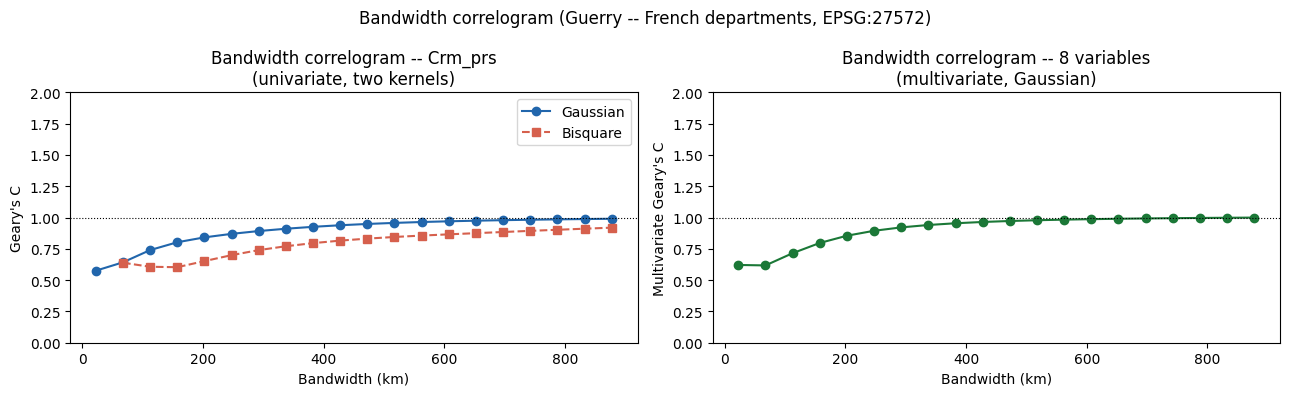

Gaussian  C range: 0.576 -- 0.990
Bisquare  C range: nan -- nan
Multivar  C range: 0.618 -- 1.000


In [7]:
res_gauss = gearygram(
    gdf[['Crm_prs']], gdf,
    max_distance=MAX_DIST, kernel='gaussian', n_bins=20,
)
res_bisq = gearygram(
    gdf[['Crm_prs']], gdf,
    max_distance=MAX_DIST, kernel='bisquare', n_bins=20,
)
res_multi = gearygram(
    gdf[VARS_MULTI], gdf,
    max_distance=MAX_DIST, kernel='gaussian', n_bins=20,
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=False)

ax = axes[0]
ax.plot(res_gauss.bin_centers / 1e3, res_gauss.C, 'o-', label='Gaussian', color='#2166ac')
ax.plot(res_bisq.bin_centers / 1e3, res_bisq.C, 's--', label='Bisquare', color='#d6604d')
ax.axhline(1, color='k', lw=0.8, ls=':')
ax.set_xlabel('Bandwidth (km)')
ax.set_ylabel("Geary's C")
ax.set_title('Bandwidth correlogram -- Crm_prs\n(univariate, two kernels)')
ax.legend()
ax.set_ylim(0, 2)

ax = axes[1]
ax.plot(res_multi.bin_centers / 1e3, res_multi.C, 'o-', color='#1b7837')
ax.axhline(1, color='k', lw=0.8, ls=':')
ax.set_xlabel('Bandwidth (km)')
ax.set_ylabel("Multivariate Geary's C")
ax.set_title(f'Bandwidth correlogram -- {len(VARS_MULTI)} variables\n(multivariate, Gaussian)')
ax.set_ylim(0, 2)

fig.suptitle('Bandwidth correlogram (Guerry -- French departments, EPSG:27572)')
fig.tight_layout()
plt.show()
print(f'Gaussian  C range: {res_gauss.C.min():.3f} -- {res_gauss.C.max():.3f}')
print(f'Bisquare  C range: {res_bisq.C.min():.3f} -- {res_bisq.C.max():.3f}')
print(f'Multivar  C range: {res_multi.C.min():.3f} -- {res_multi.C.max():.3f}')

## kNN mode (`max_k`)

`gearygram(..., max_k=K)` evaluates the cumulative kNN Geary's C for $k = 1, 2, ..., K$.  At each $k$ every observation's $k$-nearest neighbours are included; the adaptive bandwidth is set to each observation's $k$-th nearest-neighbour distance so the boundary neighbour just falls inside the kernel support.

- **Uniform** kernel (default): all k neighbours equally weighted
- **Gaussian** kernel: closer neighbours receive higher weight


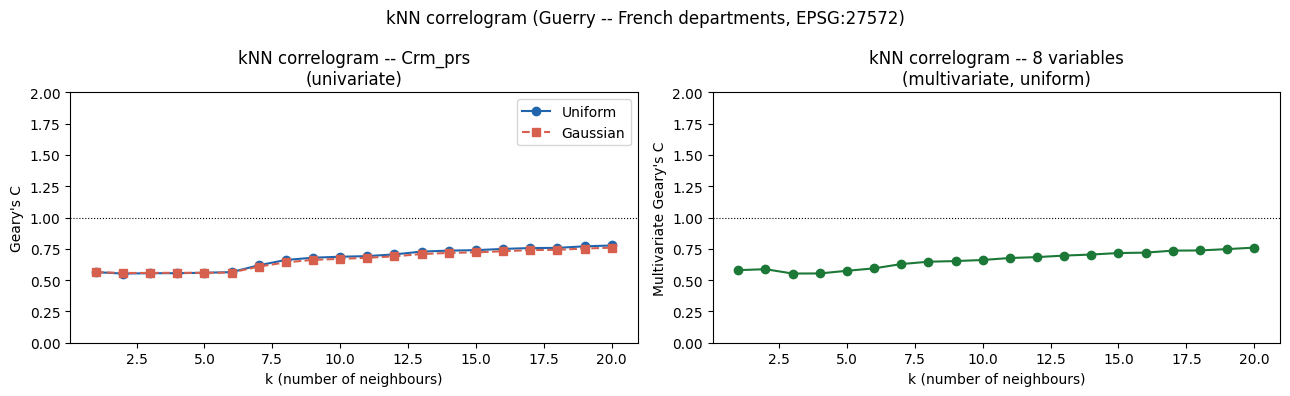

Uniform  C at k=1: 0.564,  k=20: 0.777
Gaussian C at k=1: 0.564,  k=20: 0.759


In [10]:
res_knn_unif = gearygram(gdf[['Crm_prs']], gdf, max_k=20,)
res_knn_gauss = gearygram(gdf[['Crm_prs']], gdf, max_k=20, kernel='gaussian')
res_knn_multi = gearygram(gdf[VARS_MULTI], gdf, max_k=20)

fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=False)

ax = axes[0]
ax.plot(res_knn_unif.bin_centers, res_knn_unif.C, 'o-', label='Uniform', color='#2166ac')
ax.plot(res_knn_gauss.bin_centers, res_knn_gauss.C, 's--', label='Gaussian', color='#d6604d')
ax.axhline(1, color='k', lw=0.8, ls=':')
ax.set_xlabel('k (number of neighbours)')
ax.set_ylabel("Geary's C")
ax.set_title('kNN correlogram -- Crm_prs\n(univariate)')
ax.legend()
ax.set_ylim(0, 2)

ax = axes[1]
ax.plot(res_knn_multi.bin_centers, res_knn_multi.C, 'o-', color='#1b7837')
ax.axhline(1, color='k', lw=0.8, ls=':')
ax.set_xlabel('k (number of neighbours)')
ax.set_ylabel("Multivariate Geary's C")
ax.set_title(f'kNN correlogram -- {len(VARS_MULTI)} variables\n(multivariate, uniform)')
ax.set_ylim(0, 2)

fig.suptitle('kNN correlogram (Guerry -- French departments, EPSG:27572)')
fig.tight_layout()
plt.show()
print(f'Uniform  C at k=1: {res_knn_unif.C[0]:.3f},  k=20: {res_knn_unif.C[-1]:.3f}')
print(f'Gaussian C at k=1: {res_knn_gauss.C[0]:.3f},  k=20: {res_knn_gauss.C[-1]:.3f}')

## Nonparametric LOWESS mode (`nonparametric=True`)

This mimics the nonparametric Moran `correlogram` (see [`esda.correlogram`](https://github.com/pysal/esda)), where a LOWESS smooth is fit directly to the per-pair Geary contributions (||z_i - z_j||^2 / 2p) as a function of squared spatial distance. No kernel or bandwidth choice is needed.  The result reveals the natural shape of autocorrelation decay.

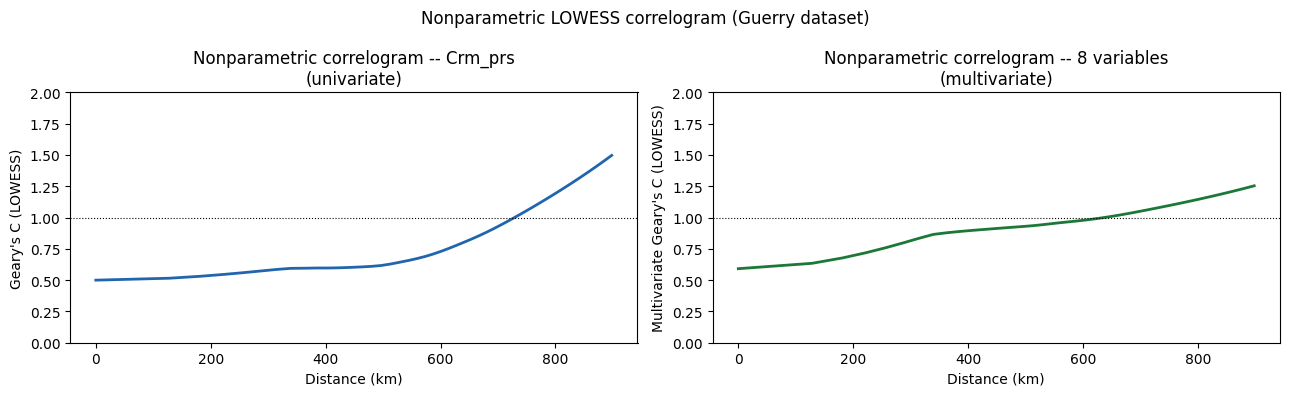

In [11]:
res_np_univ = gearygram(
    gdf[['Crm_prs']], gdf,
    nonparametric=True, max_distance=MAX_DIST, n_bins=50,
)
res_np_multi = gearygram(
    gdf[VARS_MULTI], gdf,
    nonparametric=True, max_distance=MAX_DIST, n_bins=50,
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=False)

ax = axes[0]
ax.plot(res_np_univ.bin_centers / 1e3, res_np_univ.C, color='#2166ac', lw=2)
ax.axhline(1, color='k', lw=0.8, ls=':')
ax.set_xlabel('Distance (km)')
ax.set_ylabel("Geary's C (LOWESS)")
ax.set_title('Nonparametric correlogram -- Crm_prs\n(univariate)')
ax.set_ylim(0, 2)

ax = axes[1]
ax.plot(res_np_multi.bin_centers / 1e3, res_np_multi.C, color='#1b7837', lw=2)
ax.axhline(1, color='k', lw=0.8, ls=':')
ax.set_xlabel('Distance (km)')
ax.set_ylabel("Multivariate Geary's C (LOWESS)")
ax.set_title(f'Nonparametric correlogram -- {len(VARS_MULTI)} variables\n(multivariate)')
ax.set_ylim(0, 2)

fig.suptitle('Nonparametric LOWESS correlogram (Guerry dataset)')
fig.tight_layout()
plt.show()

## Comparison: all three modes

The three modes are complementary:

- **Bandwidth**: explicit scale control; Gaussian is smooth, bisquare is sparser
- **kNN**: natural for irregular sampling, aggregates at topological scale
- **Nonparametric**: fewer assumptions, shows fine structure

All three converge toward 1 at large distances (spatial independence beyond the autocorrelation range).


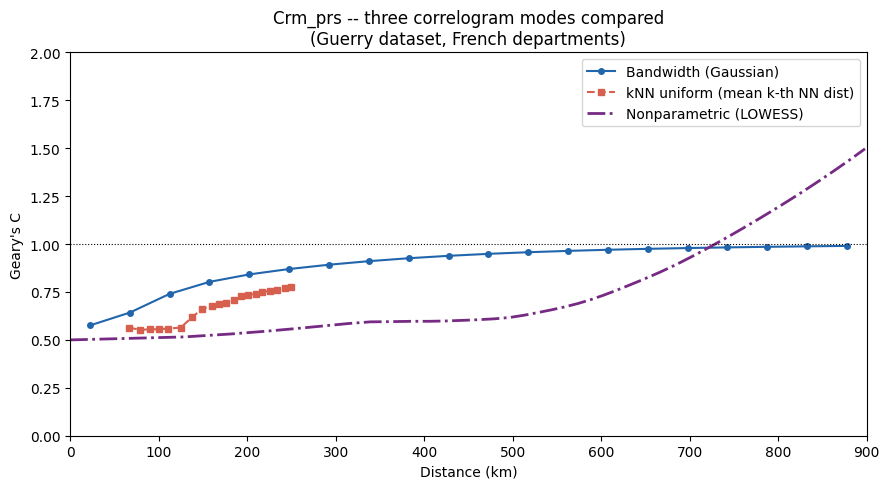

In [12]:
from scipy.spatial import cKDTree

coords = numpy.column_stack([gdf.geometry.centroid.x, gdf.geometry.centroid.y])
tree = cKDTree(coords)
dists_k, _ = tree.query(coords, k=21)
knn_mean_dist = numpy.array([dists_k[:, k].mean() for k in range(1, 21)])

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(res_gauss.bin_centers / 1e3, res_gauss.C,
        'o-', lw=1.5, ms=4, color='#2166ac', label='Bandwidth (Gaussian)')
ax.plot(knn_mean_dist / 1e3, res_knn_unif.C,
        's--', lw=1.5, ms=4, color='#d6604d', label='kNN uniform (mean k-th NN dist)')
ax.plot(res_np_univ.bin_centers / 1e3, res_np_univ.C,
        lw=2, color='#762a83', ls='-.', label='Nonparametric (LOWESS)')
ax.axhline(1, color='k', lw=0.8, ls=':')
ax.set_xlabel('Distance (km)')
ax.set_ylabel("Geary's C")
ax.set_title('Crm_prs -- three correlogram modes compared\n(Guerry dataset, French departments)')
ax.legend()
ax.set_xlim(0, MAX_DIST / 1e3)
ax.set_ylim(0, 2)
fig.tight_layout()
plt.show()